# 🌍 Global Economic Inequality & Poverty Analysis (1980–2024)

This project analyzes global inequality, poverty, and economic growth patterns.

## Objectives
- Study global poverty trends
- Analyze inequality (Gini, income share)
- Compare countries
- Detect economic imbalance
- Build predictive insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("archive/disuguaglianza-economica-globale-e-povert-1980-2024.csv")

df.columns = df.columns.str.strip()

df.head()

,country,year,iso_code,population,gdp,gdp_per_capita,poverty_rate,gini_index,income_top1,income_top10,income_bottom50
0,Afghanistan,1980,AFG,13169313,1.532984e+10,1164.06,NaN,NaN,16.22,41.94,17.17
1,Afghanistan,1981,AFG,11937586,1.564534e+10,1310.60,NaN,NaN,16.22,41.94,17.17
2,Afghanistan,1982,AFG,10991380,1.598041e+10,1453.90,NaN,NaN,16.22,41.94,17.17
3,Afghanistan,1983,AFG,10917985,1.675533e+10,1534.65,NaN,NaN,16.22,41.94,17.17
4,Afghanistan,1984,AFG,11190222,1.707215e+10,1525.63,NaN,NaN,16.22,41.94,17.17


In [4]:
df.info()

# convert types
df["year"] = df["year"].astype(int)

# fill missing carefully
df = df.sort_values(["country", "year"])
df = df.groupby("country").apply(lambda x: x.fillna(method="ffill")).reset_index(drop=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8955 entries, 0 to 8954
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          8955 non-null   object 
 1   year             8955 non-null   int64  
 2   iso_code         8955 non-null   object 
 3   population       8955 non-null   int64  
 4   gdp              7035 non-null   float64
 5   gdp_per_capita   7035 non-null   float64
 6   poverty_rate     2207 non-null   float64
 7   gini_index       2207 non-null   float64
 8   income_top1      8280 non-null   float64
 9   income_top10     8280 non-null   float64
 10  income_bottom50  8280 non-null   float64
dtypes: float64(7), int64(2), object(2)
memory usage: 769.7+ KB


C:\Users\thear\AppData\Local\Temp\ipykernel_1108\2515379599.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.groupby("country").apply(lambda x: x.fillna(method="ffill")).reset_index(drop=True)
C:\Users\thear\AppData\Local\Temp\ipykernel_1108\2515379599.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("country").apply(lambda x: x.fillna(method="ffill")).reset_index(drop=True)


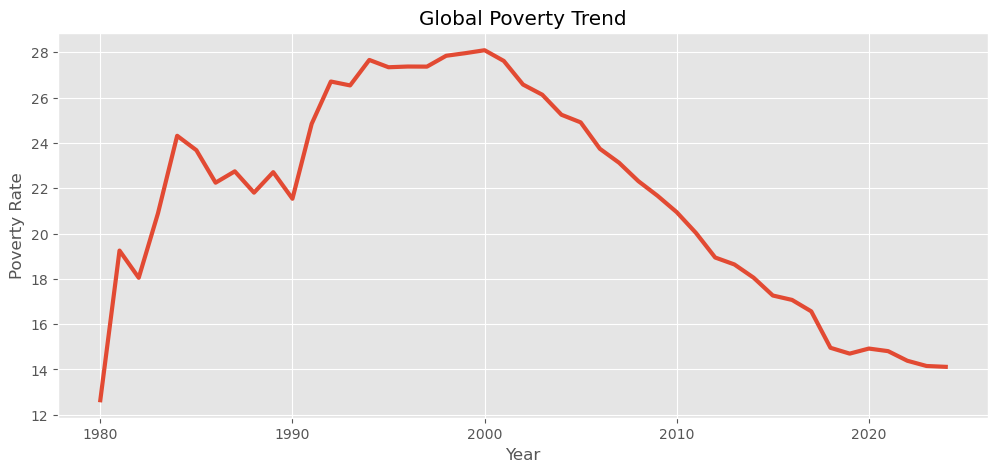

In [6]:
global_poverty = df.groupby("year")["poverty_rate"].mean()

plt.figure(figsize=(12,5))
plt.plot(global_poverty.index, global_poverty.values, linewidth=3)

plt.title("Global Poverty Trend")
plt.xlabel("Year")
plt.ylabel("Poverty Rate")

plt.show()

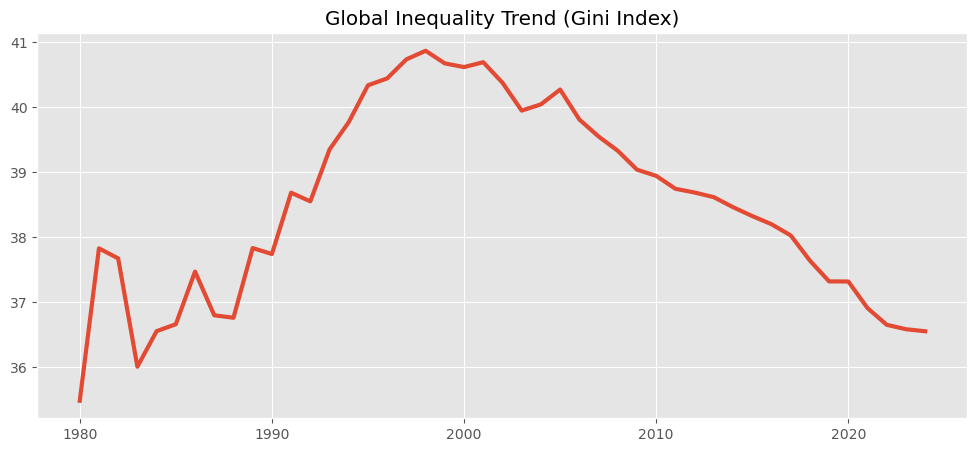

In [7]:
gini = df.groupby("year")["gini_index"].mean()

plt.figure(figsize=(12,5))
plt.plot(gini.index, gini.values, linewidth=3)

plt.title("Global Inequality Trend (Gini Index)")

plt.show()

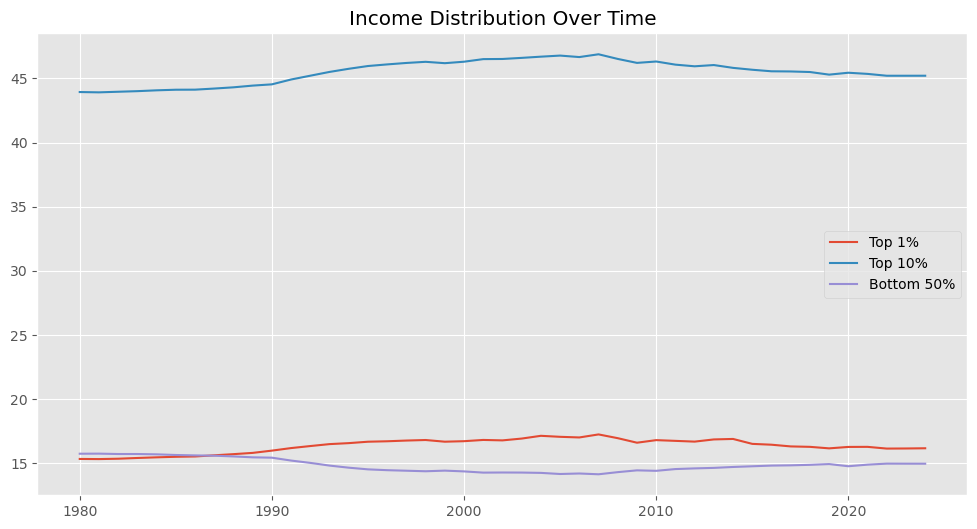

In [8]:
income = df.groupby("year")[["income_top1", "income_top10", "income_bottom50"]].mean()

plt.figure(figsize=(12,6))

plt.plot(income.index, income["income_top1"], label="Top 1%")
plt.plot(income.index, income["income_top10"], label="Top 10%")
plt.plot(income.index, income["income_bottom50"], label="Bottom 50%")

plt.legend()
plt.title("Income Distribution Over Time")

plt.show()

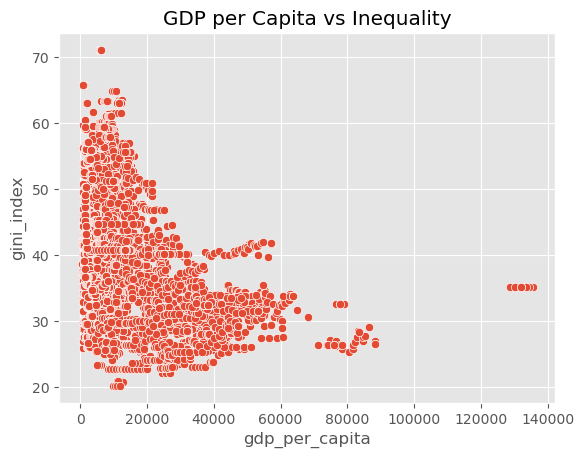

In [9]:
sns.scatterplot(
    x=df["gdp_per_capita"],
    y=df["gini_index"]
)

plt.title("GDP per Capita vs Inequality")

plt.show()

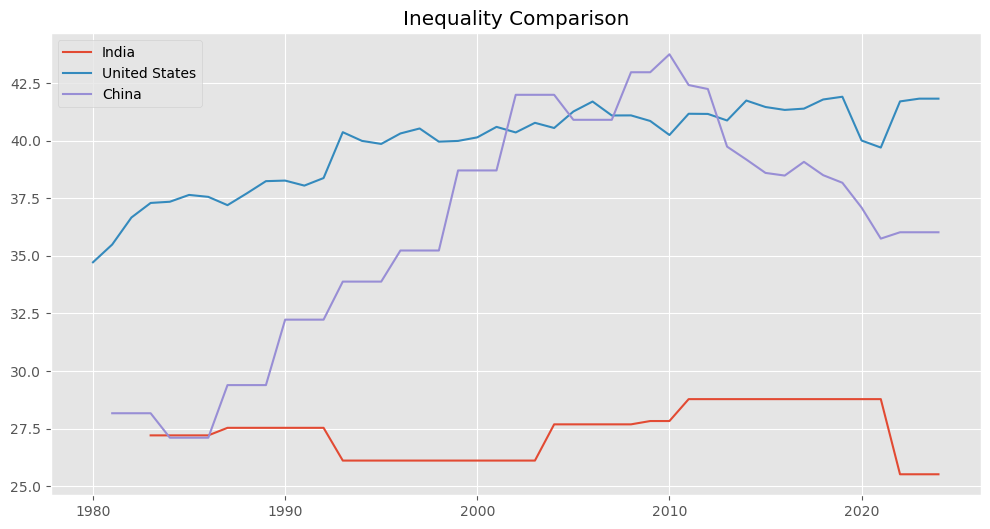

In [10]:
countries = ["India", "United States", "China"]

plt.figure(figsize=(12,6))

for c in countries:
    temp = df[df["country"] == c]
    plt.plot(temp["year"], temp["gini_index"], label=c)

plt.legend()
plt.title("Inequality Comparison")

plt.show()

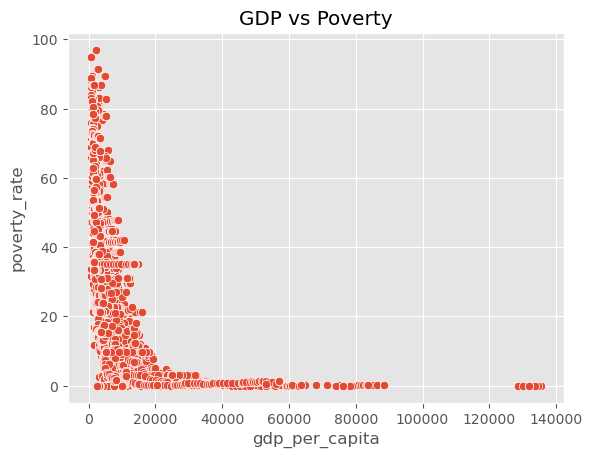

In [11]:
sns.scatterplot(
    x=df["gdp_per_capita"],
    y=df["poverty_rate"]
)

plt.title("GDP vs Poverty")

plt.show()

In [12]:
df["inequality_score"] = (
    df["income_top10"] - df["income_bottom50"]
)

In [13]:
worst = df.groupby("country")["inequality_score"].mean().sort_values(ascending=False).head(10)

worst

country
Namibia                     65.989556
Botswana                    56.942667
Malawi                      56.589333
Chile                       55.304000
Colombia                    55.003778
Central African Republic    53.658889
Comoros                     52.217111
Mexico                      51.772889
Mozambique                  51.368000
Zambia                      49.929556
Name: inequality_score, dtype: float64

In [14]:
features = df[[
    "gdp_per_capita",
    "poverty_rate",
    "gini_index"
]].dropna()

scaler = StandardScaler()
X = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
df.loc[features.index, "cluster"] = kmeans.fit_predict(X)

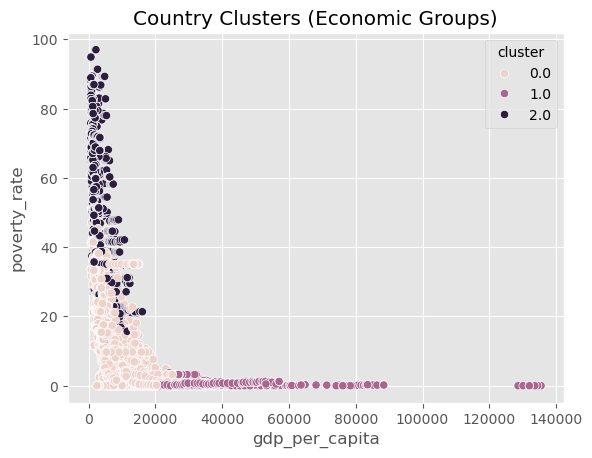

In [15]:
sns.scatterplot(
    x=df["gdp_per_capita"],
    y=df["poverty_rate"],
    hue=df["cluster"]
)

plt.title("Country Clusters (Economic Groups)")

plt.show()

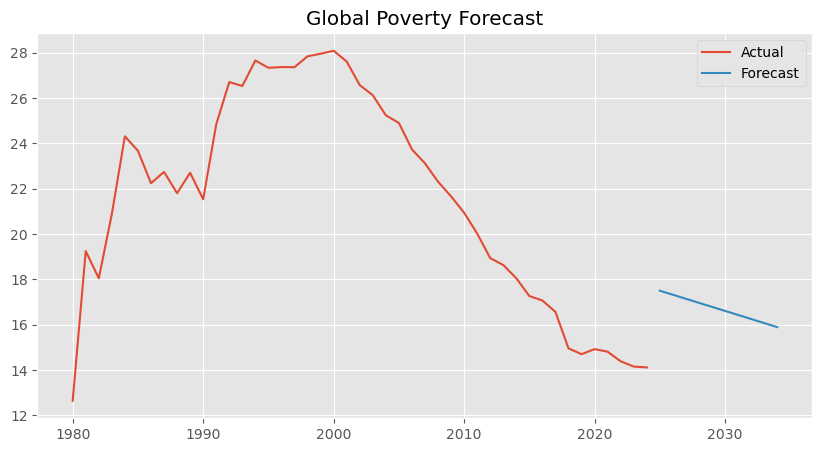

In [16]:
g = global_poverty.reset_index()
g.columns = ["year", "poverty"]

g["time"] = np.arange(len(g))

model = LinearRegression()
model.fit(g[["time"]], g["poverty"])

future = pd.DataFrame({
    "time": np.arange(len(g), len(g)+10)
})

pred = model.predict(future)

future_years = np.arange(g["year"].iloc[-1]+1, g["year"].iloc[-1]+11)

plt.figure(figsize=(10,5))

plt.plot(g["year"], g["poverty"], label="Actual")
plt.plot(future_years, pred, label="Forecast")

plt.legend()
plt.title("Global Poverty Forecast")

plt.show()

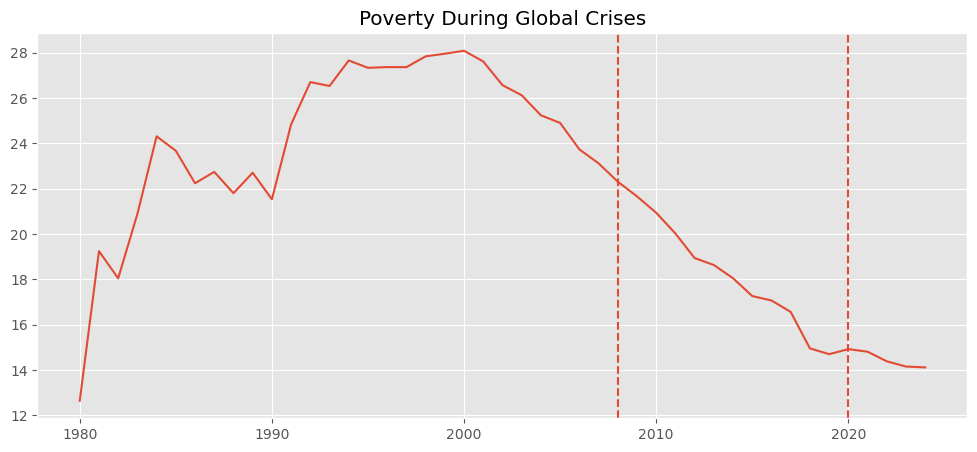

In [17]:
plt.figure(figsize=(12,5))

plt.plot(global_poverty.index, global_poverty.values)

plt.axvline(2008, linestyle="--")
plt.axvline(2020, linestyle="--")

plt.title("Poverty During Global Crises")

plt.show()

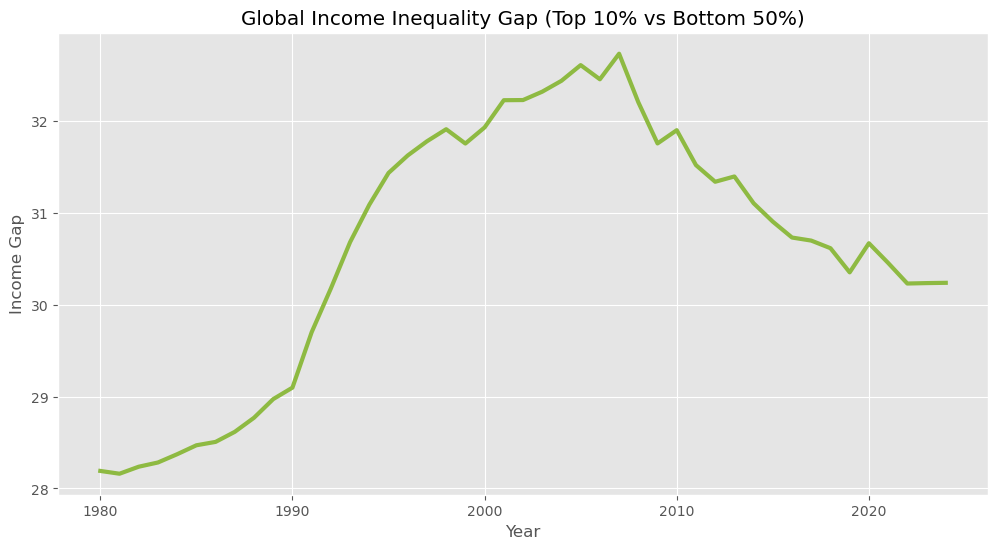

In [18]:
gap = df.groupby("year")[["income_top10", "income_bottom50"]].mean()

gap["gap"] = gap["income_top10"] - gap["income_bottom50"]

plt.figure(figsize=(12,6))

# glow effect
for i in range(1,6):
    plt.plot(gap.index, gap["gap"], alpha=0.1)

plt.plot(gap.index, gap["gap"], linewidth=3)

plt.title("Global Income Inequality Gap (Top 10% vs Bottom 50%)")
plt.xlabel("Year")
plt.ylabel("Income Gap")

plt.show()

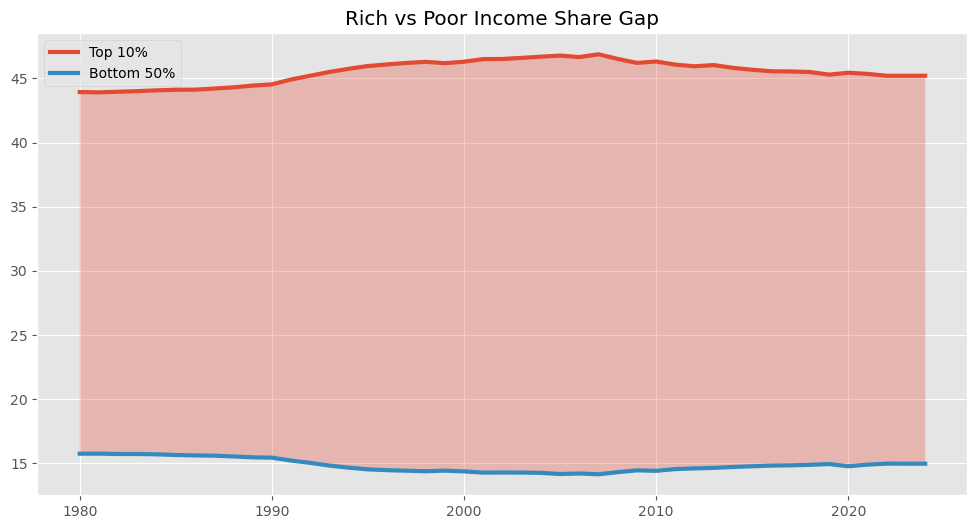

In [19]:
plt.figure(figsize=(12,6))

plt.plot(gap.index, gap["income_top10"], label="Top 10%", linewidth=3)
plt.plot(gap.index, gap["income_bottom50"], label="Bottom 50%", linewidth=3)

plt.fill_between(
    gap.index,
    gap["income_top10"],
    gap["income_bottom50"],
    alpha=0.3
)

plt.legend()
plt.title("Rich vs Poor Income Share Gap")

plt.show()

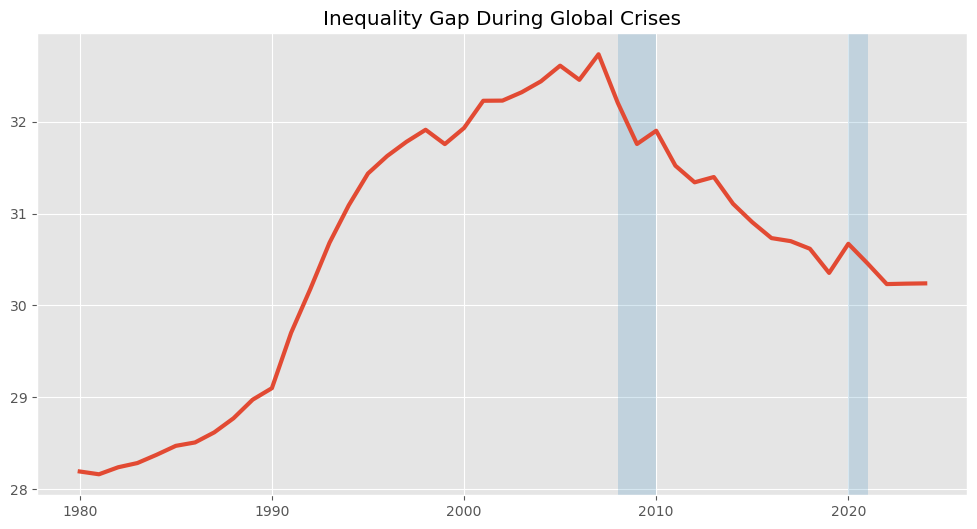

In [20]:
plt.figure(figsize=(12,6))

plt.plot(gap.index, gap["gap"], linewidth=3)

plt.axvspan(2008, 2010, alpha=0.2)
plt.axvspan(2020, 2021, alpha=0.2)

plt.title("Inequality Gap During Global Crises")

plt.show()

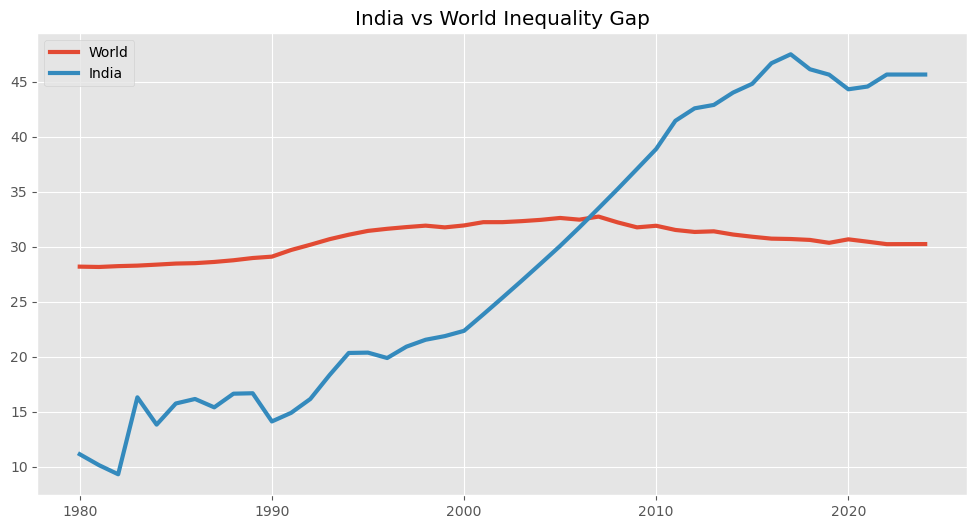

In [21]:
india = df[df["country"] == "India"]

india_gap = india.groupby("year")[["income_top10", "income_bottom50"]].mean()
india_gap["gap"] = india_gap["income_top10"] - india_gap["income_bottom50"]

global_gap = gap["gap"]

plt.figure(figsize=(12,6))

plt.plot(global_gap.index, global_gap, label="World", linewidth=3)
plt.plot(india_gap.index, india_gap["gap"], label="India", linewidth=3)

plt.legend()
plt.title("India vs World Inequality Gap")

plt.show()

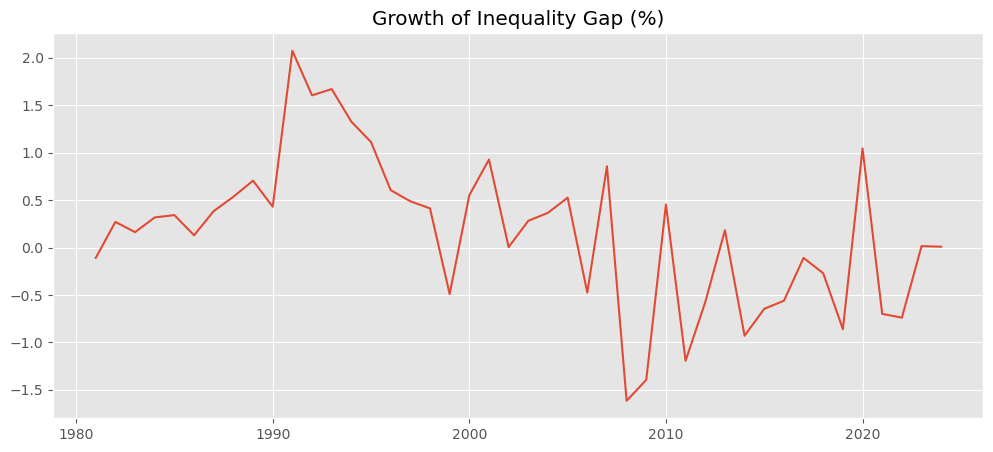

In [22]:
gap["gap_growth"] = gap["gap"].pct_change() * 100

plt.figure(figsize=(12,5))

plt.plot(gap.index, gap["gap_growth"])

plt.title("Growth of Inequality Gap (%)")

plt.show()

In [23]:
race_df = df.copy()

race_df["gap"] = race_df["income_top10"] - race_df["income_bottom50"]

race_df = race_df.dropna(subset=["gap"])


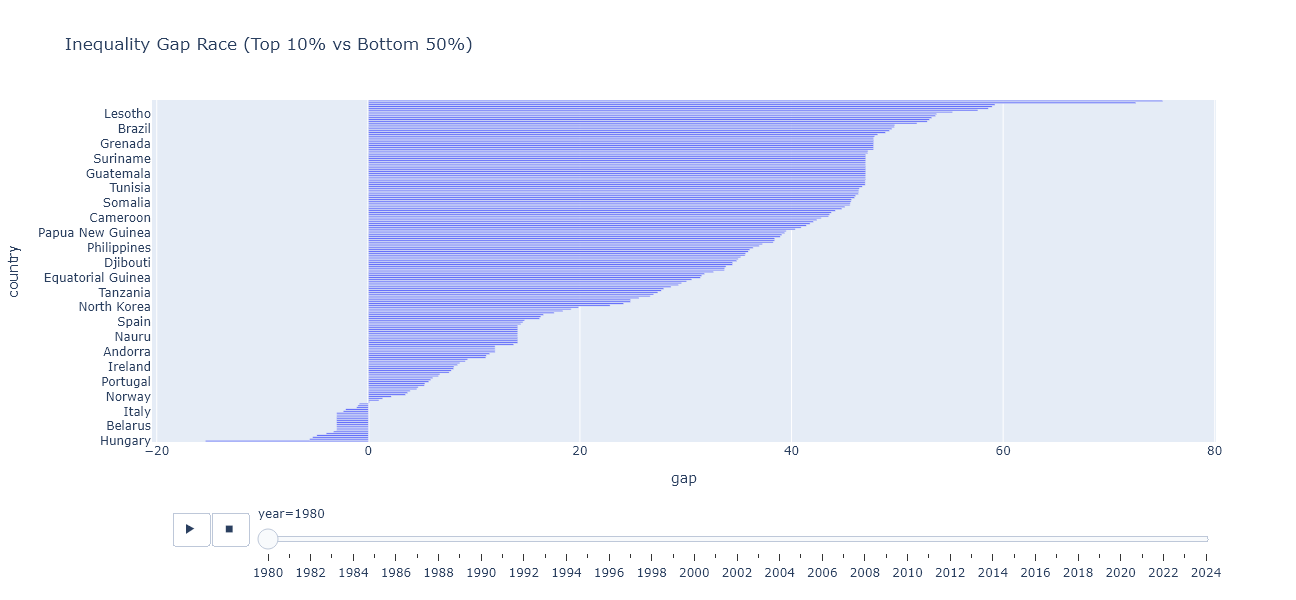

In [24]:
import plotly.express as px

fig = px.bar(
    race_df,
    x="gap",
    y="country",
    animation_frame="year",
    orientation="h",
    title="Inequality Gap Race (Top 10% vs Bottom 50%)",
    height=600
)

fig.update_layout(yaxis={"categoryorder":"total ascending"})

fig.show()

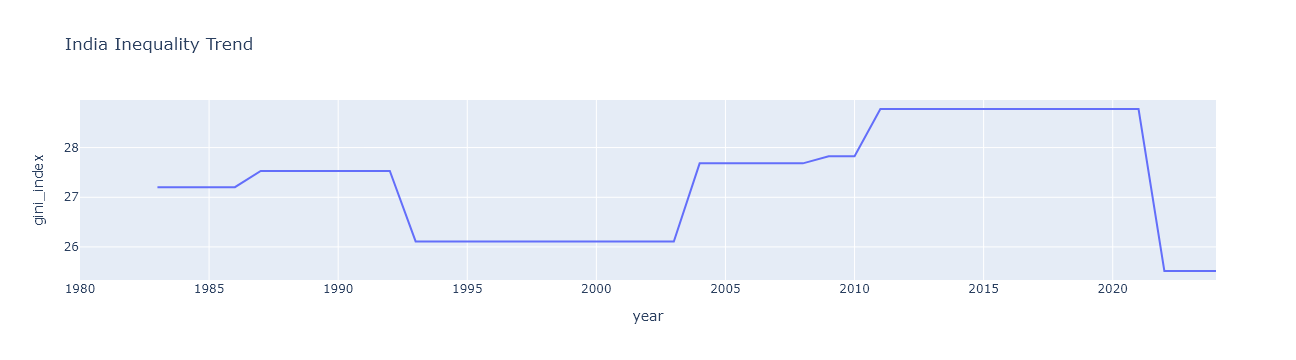

In [25]:

import plotly.express as px

countries = df["country"].unique()

country = "India"  # change this manually

temp = df[df["country"] == country]

fig = px.line(
    temp,
    x="year",
    y="gini_index",
    title=f"{country} Inequality Trend"
)

fig.show()

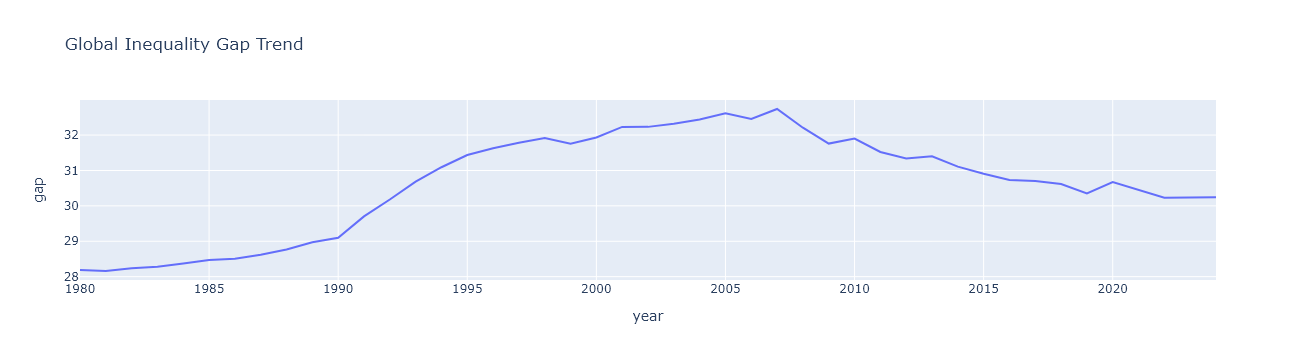

In [26]:
fig = px.line(
    gap.reset_index(),
    x="year",
    y="gap",
    title="Global Inequality Gap Trend"
)

fig.show()

C:\Users\thear\AppData\Local\Temp\ipykernel_1108\1889298124.py:5: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


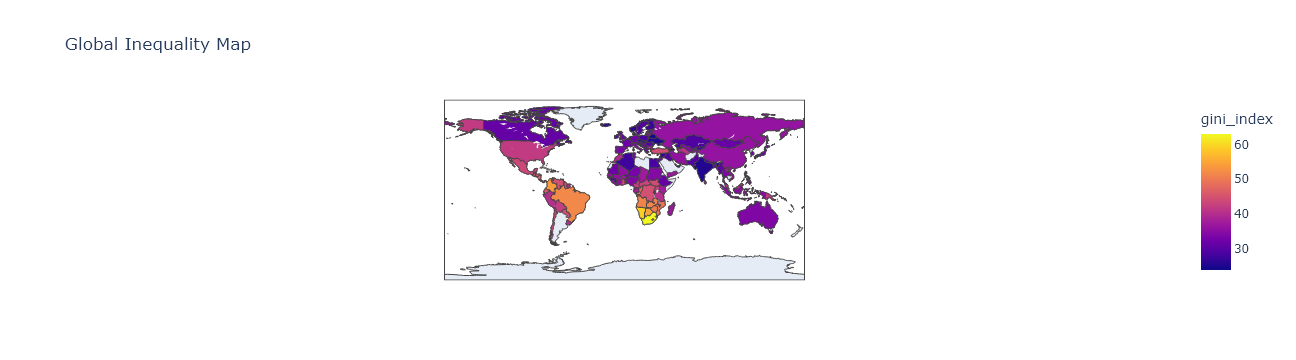

In [27]:
latest_year = df["year"].max()

map_df = df[df["year"] == latest_year]

fig = px.choropleth(
    map_df,
    locations="country",
    locationmode="country names",
    color="gini_index",
    title="Global Inequality Map"
)

fig.show()